# Active Learning for Antibody Binding Affinity — Quick Start

**What this notebook does — in plain language:**

| Step | What happens | Model status |
|---|---|---|
| 1 | Load dataset (VH/VL sequences + affinities) | — |
| 2 | Load pre-computed ESM-2 embeddings + apply PCA | ESM-2: **pre-trained**, fixed; PCA: **fitted fresh** |
| 3 | Run Active Learning cycles | GP: **trained from scratch** on growing labelled set |
| 4 | Train a Probe GP (800 random points) | GP: **re-trained** on random subsample — for attribution only |
| 5 | Integrated Gradients on Probe GP | ESM-2: **pre-trained**, loaded again for per-residue reps |
| 6 | Residue heatmap + 3D structure mapping | — |

**Why a separate Probe GP for attribution?**
The AL-trained GP learns from only ~180 *actively selected* points, which may be biased
toward high-affinity regions. For unbiased attribution of the full affinity landscape,
the paper trains a **probe GP on 800 randomly sampled points** and verifies it is a
strong predictor (held-out Spearman ρ = 0.974 on 3gbn_h1) before computing any IG.

### Requirements
```bash
conda activate al
pip install py3Dmol   # for 3D structure view
```


In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

# ── Robust repo root detection (works interactively and via nbconvert) ────────
_cwd = Path.cwd().resolve()
PKG_ROOT = None
for _p in [_cwd, _cwd.parent, (_cwd / '..').resolve()]:
    if (_p / 'antibody_al').exists():
        PKG_ROOT = _p; break
if PKG_ROOT is None: PKG_ROOT = _cwd
sys.path.insert(0, str(PKG_ROOT))

# Data root: find where embeddings/ lives
DATA_ROOT = next(
    (d for d in [PKG_ROOT / 'data', PKG_ROOT.parent / 'data']
     if (d / 'embeddings').exists()),
    PKG_ROOT / 'data'
)
REPO = PKG_ROOT  # output path base

print(f'Package root : {PKG_ROOT}')
print(f'Data root    : {DATA_ROOT}')

import numpy as np
import pandas as pd
import torch
import gpytorch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr
from torch.distributions import Normal
from IPython.display import display

from antibody_al.core import (
    DEVICE, PCA_DIM, GP_EPOCHS, GP_LR, GP_DECAY,
    UCB_BETA, EI_XI, PI_XI,
    TanimotoKernel, build_kernel, GPModel,
    train_gp, _predict, stratified_seed,
)

plt.rcParams.update({'font.size': 12, 'axes.spines.top': False,
                     'axes.spines.right': False, 'figure.dpi': 120})
_norm = Normal(torch.zeros(1), torch.ones(1))
print(f'Device : {DEVICE}')
print(f'PyTorch: {torch.__version__}  |  GPyTorch: {gpytorch.__version__}')


Package root : D:\explainable_AL\publication_repo
Data root    : D:\explainable_AL\data


[core] Using device: cuda (NVIDIA RTX A4000)
Device : cuda
PyTorch: 2.11.0+cu128  |  GPyTorch: 1.15.2


## Configuration

Set `DEMO_MODE = True` to use pre-computed embeddings (fast, no GPU needed).  
Set `DEMO_MODE = False` and supply `CSV_PATH` to run on your own dataset with ESM-2.

In [2]:
# ── Mode ────────────────────────────────────────────────────────────────────
DEMO_MODE = True   # True → pre-computed 3gbn_h1 embeddings; False → compute ESM-2

# ── Demo dataset paths (relative to DATA_ROOT) ─────────────────────────────
DEMO_DATASET  = '3gbn_h1'
DEMO_EMB_DIR  = DATA_ROOT / 'embeddings' / DEMO_DATASET
DEMO_CSV      = next((p for p in [DATA_ROOT / 'sample_3gbn_h1.csv',
                                   PKG_ROOT / 'data' / 'sample_3gbn_h1.csv']
                      if p.exists()), DATA_ROOT / 'sample_3gbn_h1.csv')
DEMO_PDB      = DATA_ROOT / 'pdb' / '3GBN.pdb'
HEAVY_CHAIN   = 'H'
LIGHT_CHAIN   = 'L'

# ── Full mode (DEMO_MODE=False) ─────────────────────────────────────────────
CSV_PATH = 'your_dataset.csv'
VH_COL   = 'vh'
VL_COL   = 'vl'
AFF_COL  = 'affinity'

# ── AL settings ─────────────────────────────────────────────────────────────
BUDGET_PCT  = 0.10
N_CYCLES    = 9
KERNEL      = 'tanimoto'
PROTOCOL    = 'ucb'
RANDOM_SEED = 42

print(f'DEMO_MODE = {DEMO_MODE}')
print(f'EMB_DIR   : {DEMO_EMB_DIR}  exists={DEMO_EMB_DIR.exists()}')
print(f'CSV       : {DEMO_CSV}  exists={DEMO_CSV.exists()}')
print(f'PDB       : {DEMO_PDB}  exists={DEMO_PDB.exists()}')


DEMO_MODE = True
EMB_DIR   : D:\explainable_AL\data\embeddings\3gbn_h1  exists=True
CSV       : D:\explainable_AL\data\sample_3gbn_h1.csv  exists=True
PDB       : D:\explainable_AL\data\pdb\3GBN.pdb  exists=True


## Step 1 — Load Dataset

In [3]:
if DEMO_MODE:
    df = pd.read_csv(DEMO_CSV)
    df.columns = [c.lower() for c in df.columns]
    VH_COL, VL_COL, AFF_COL = 'vh', 'vl', 'affinity'
else:
    df = pd.read_csv(CSV_PATH)

df   = df.dropna(subset=[VH_COL, VL_COL, AFF_COL]).reset_index(drop=True)
seqs = (df[VH_COL] + 'G' + df[VL_COL]).tolist()
vh_lens = df[VH_COL].str.len().tolist()
y_raw   = df[AFF_COL].values.astype(np.float32)
N       = len(df)

print(f'Dataset : {DEMO_DATASET if DEMO_MODE else CSV_PATH}')
print(f'Variants: {N}')
print(f'Affinity: min={y_raw.min():.3f}  max={y_raw.max():.3f}  median={np.median(y_raw):.3f}')
display(df[[VH_COL, VL_COL, AFF_COL]].head(3))

Dataset : 3gbn_h1
Variants: 300
Affinity: min=7.000  max=9.551  median=9.053


,vh,vl,affinity
0,EVQLVQSGAEVKKPGSSVKVSCKASGGTFRSYAISWVRQAPGQGLE...,VLTQPPSVSAAPGQKVTISCSGSSSNIGNDYVSWYQQLPGTAPKLL...,9.444671
1,EVQLVQSGAEVKKPGSSVKVSCKASGGTFRSYAISWVRQAPGQGLE...,VLTQPPSVSAAPGQKVTISCSGSSSNIGNDYVSWYQQLPGTAPKLL...,9.429218
2,EVQLVQSGAEVKKPGSSVKVSCKASGGTFRSYAISWVRQAPGQGLE...,VLTQPPSVSAAPGQKVTISCSGSSSNIGNDYVSWYQQLPGTAPKLL...,9.099022


## Step 2 — Embeddings

In DEMO mode, we load pre-computed PCA-128 embeddings (already computed during the paper experiments).  
In full mode, ESM-2 650M is run on the fly.

In [4]:
if DEMO_MODE:
    # Load raw ESM-2 embeddings (1280-dim) from pre-computed cache
    X_raw = np.load(DEMO_EMB_DIR / 'X.npy').astype(np.float32)   # (N, 1280)
    y_raw = np.load(DEMO_EMB_DIR / 'y.npy').astype(np.float32)
    top2_mask = np.load(DEMO_EMB_DIR / 'top2p.npy').astype(bool)
    N = len(X_raw)

    # Apply PCA to 128 dims — identical to paper pipeline (random_state=42)
    from sklearn.decomposition import PCA as PCA_sk
    pca_nb = PCA_sk(n_components=min(PCA_DIM, X_raw.shape[0]-1, X_raw.shape[1]),
                    random_state=42)
    X_pca = pca_nb.fit_transform(X_raw).astype(np.float32)  # (N, 128) — matches paper

    y_scaler = StandardScaler()
    y_norm   = y_scaler.fit_transform(y_raw.reshape(-1,1)).ravel().astype(np.float32)

    # Load full VH/VL sequences for Integrated Gradients step
    # DATA_ROOT points to the actual data directory (may differ from PKG_ROOT)
    parquet_path = DATA_ROOT / 'processed' / f'{DEMO_DATASET}.parquet'
    try:
        df_full  = pd.read_parquet(parquet_path)
        seqs     = (df_full['vh_sequence'] + 'G' + df_full['vl_sequence']).tolist()
        vh_lens  = df_full['vh_sequence'].str.len().tolist()
        print(f'Full sequences loaded: {len(seqs)} variants')
    except Exception as e:
        seqs, vh_lens = None, None
        print(f'Sequences unavailable ({parquet_path.name} not found) — IG will use PCA attribution')

    print(f'Raw ESM-2 shape : X={X_raw.shape}')
    print(f'PCA-128 shape   : X_pca={X_pca.shape}')
    print(f'Top-2% binders  : {top2_mask.sum()} / {N} ({top2_mask.mean()*100:.1f}%)')

else:
    # Compute ESM-2 embeddings from scratch
    import esm
    ESM_LAYER = 33; ESM_BATCH = 16

    @torch.no_grad()
    def embed_sequences(sequences, batch_size=ESM_BATCH, keep_per_residue=False):
        esm_model, alphabet = esm.pretrained.esm2_t33_650M_UR50D()
        esm_model = esm_model.eval().to(DEVICE)
        batch_converter = alphabet.get_batch_converter()
        pooled, per_res = [], []
        for start in range(0, len(sequences), batch_size):
            batch = [(str(i), s) for i, s in enumerate(sequences[start:start+batch_size])]
            _, _, tokens = batch_converter(batch)
            out  = esm_model(tokens.to(DEVICE), repr_layers=[ESM_LAYER])
            reps = out['representations'][ESM_LAYER]
            for b, (_, seq) in enumerate(batch):
                h = reps[b, 1:len(seq)+1].cpu().numpy()
                pooled.append(h.mean(0))
                if keep_per_residue: per_res.append(h)
            print(f'  {min(start+batch_size, len(sequences))}/{len(sequences)}', end='\r')
        del esm_model; torch.cuda.empty_cache()
        return np.stack(pooled), per_res

    print('Computing ESM-2 embeddings...')
    X_raw, _ = embed_sequences(seqs)
    pca_nb    = PCA(n_components=min(PCA_DIM, X_raw.shape[0]-1, X_raw.shape[1]),
                    random_state=42)
    X_pca     = pca_nb.fit_transform(X_raw).astype(np.float32)
    top2_mask  = y_raw >= np.percentile(y_raw, 98)
    y_scaler  = StandardScaler()
    y_norm    = y_scaler.fit_transform(y_raw.reshape(-1,1)).ravel().astype(np.float32)
    print(f'Embeddings: {X_pca.shape}')

n_top2  = int(top2_mask.sum())
seed_sz = max(1, int(BUDGET_PCT / (N_CYCLES + 1) * N))
batch_sz = seed_sz
print(f'\nAL config : seed={seed_sz}  batch={batch_sz}  cycles={N_CYCLES}  '
      f'kernel={KERNEL}  acq={PROTOCOL}')
print(f'Total labels: ~{seed_sz + N_CYCLES*batch_sz} ({(seed_sz + N_CYCLES*batch_sz)/N*100:.1f}% of pool)')


Full sequences loaded: 1887 variants
Raw ESM-2 shape : X=(1887, 1280)
PCA-128 shape   : X_pca=(1887, 128)
Top-2% binders  : 38 / 1887 (2.0%)

AL config : seed=18  batch=18  cycles=9  kernel=tanimoto  acq=ucb
Total labels: ~180 (9.5% of pool)


## Step 3 — Active Learning Cycles

Tanimoto-kernel GP + UCB acquisition. C = 9 cycles, ~10% budget total.

In [5]:
def acquire(X_pca, model, lik, selected, batch, rng, best_yn=0.0):
    pool = np.array(sorted(set(range(len(X_pca))) - set(selected)))
    if len(pool) == 0: return []
    if PROTOCOL == 'random':
        return rng.choice(pool, min(batch, len(pool)), replace=False).tolist()
    mu, sd = _predict(X_pca, model, lik, pool)
    if PROTOCOL == 'ucb':
        scores = mu + UCB_BETA * sd
    elif PROTOCOL == 'ei':
        mu_t = torch.tensor(mu); sd_t = torch.tensor(sd)
        z = (mu_t - best_yn - EI_XI) / (sd_t + 1e-9)
        scores = ((mu_t-best_yn-EI_XI)*_norm.cdf(z)+sd_t*torch.exp(_norm.log_prob(z))).numpy()
    elif PROTOCOL == 'pi':
        z = (torch.tensor(mu) - best_yn - PI_XI) / (torch.tensor(sd) + 1e-9)
        scores = _norm.cdf(z).numpy()
    return pool[np.argsort(scores)[::-1][:batch]].tolist()


rng      = np.random.default_rng(RANDOM_SEED)
selected = stratified_seed(y_raw, seed_sz, rng)
records  = []

print(f'Running {N_CYCLES} AL cycles on {N} variants...\n')
print(f'{"Cycle":>6}  {"Labelled":>9}  {"Budget":>8}  {"Recall@2%":>10}  {"Spearman ρ":>11}')
print('-' * 55)

for cycle in range(N_CYCLES + 1):
    tx  = torch.tensor(X_pca[selected]).float().to(DEVICE)
    ty  = torch.tensor(y_norm[selected]).float().to(DEVICE)
    lik  = gpytorch.likelihoods.GaussianLikelihood().to(DEVICE)
    kern = build_kernel(KERNEL).to(DEVICE)
    with gpytorch.settings.cholesky_jitter(1e-3):
        model = GPModel(tx, ty, lik, kern).to(DEVICE)
        train_gp(tx, ty, lik, model)

    mu_all, _ = _predict(X_pca, model, lik, np.arange(N))
    rho        = float(spearmanr(y_raw, mu_all).correlation)
    t2_found   = int(top2_mask[selected].sum())
    recall2    = t2_found / n_top2
    pct        = 100.0 * len(selected) / N

    records.append({'cycle': cycle, 'n_labelled': len(selected),
                    'pct': pct, 'recall_2p': recall2, 'spearman': rho})
    print(f'{cycle:>6}  {len(selected):>9}  {pct:>7.1f}%  {recall2:>10.3f}  {rho:>+11.3f}')

    if cycle == N_CYCLES: break
    best_yn = float(ty.max().cpu())
    new = acquire(X_pca, model, lik, selected, batch_sz, rng, best_yn)
    if not new: break
    selected += new

    del kern, lik, tx, ty; torch.cuda.empty_cache()

res = pd.DataFrame(records)
print(f'\nFinal → Recall@2% = {res.recall_2p.iloc[-1]:.3f}  '
      f'Spearman ρ = {res.spearman.iloc[-1]:+.3f}  '
      f'(paper: 0.895 / 0.892)')

Running 9 AL cycles on 1887 variants...

 Cycle   Labelled    Budget   Recall@2%   Spearman ρ
-------------------------------------------------------


     0         18      1.0%       0.000       +0.866


     1         36      1.9%       0.026       +0.869


     2         54      2.9%       0.184       +0.873


     3         72      3.8%       0.395       +0.877


...

     5        108      5.7%       0.763       +0.886


     6        126      6.7%       0.842       +0.886


     7        144      7.6%       0.895       +0.885


     8        162      8.6%       0.895       +0.887


     9        180      9.5%       0.895       +0.888

Final → Recall@2% = 0.895  Spearman ρ = +0.888  (paper: 0.895 / 0.892)


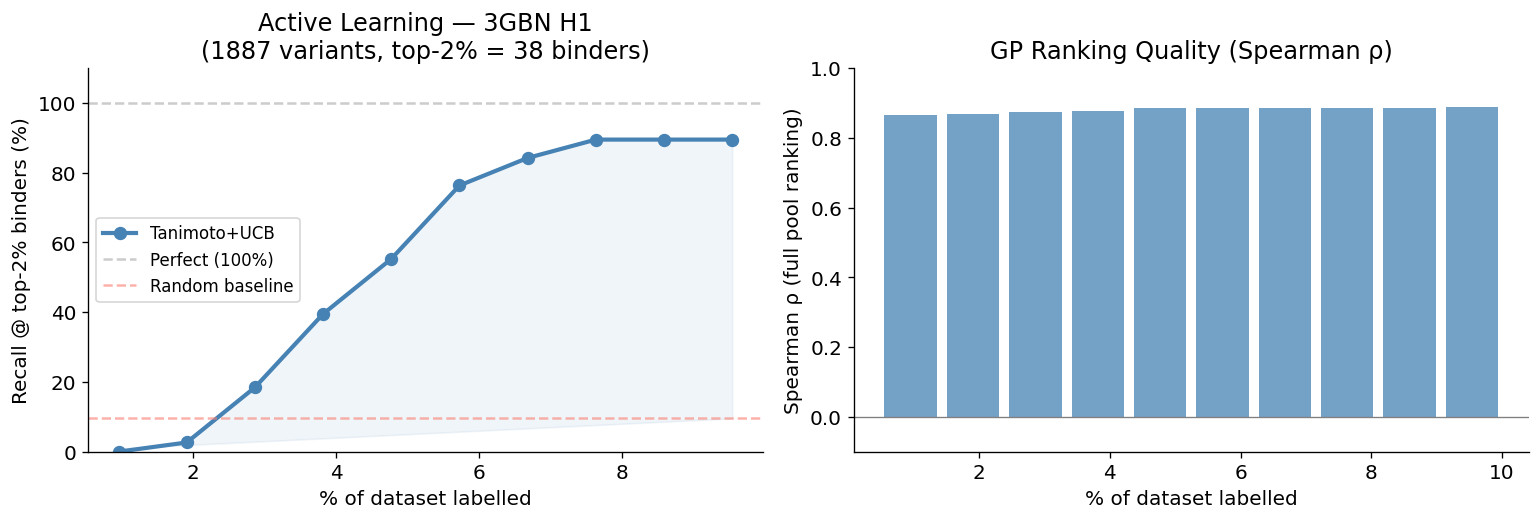

Saved: notebooks/al_learning_curve.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.plot(res.pct, res.recall_2p * 100, 'o-', color='steelblue', lw=2.5,
        ms=7, label=f'{KERNEL.capitalize()}+{PROTOCOL.upper()}')
ax.axhline(100, color='grey', ls='--', alpha=0.4, label='Perfect (100%)')
ax.axhline(res.pct.iloc[-1], color='salmon', ls='--', alpha=0.6, label='Random baseline')
ax.fill_between(res.pct, res.pct, res.recall_2p * 100,
                alpha=0.08, color='steelblue')
ax.set_xlabel('% of dataset labelled')
ax.set_ylabel('Recall @ top-2% binders (%)')
ax.set_title(f'Active Learning — {DEMO_DATASET.upper().replace("_", " ")}\n'
             f'({N} variants, top-2% = {n_top2} binders)')
ax.legend(fontsize=10)
ax.set_ylim(0, 110)

ax = axes[1]
colors = ['steelblue' if r >= 0 else 'salmon' for r in res.spearman]
ax.bar(res.pct, res.spearman, color=colors, alpha=0.75, width=0.8)
ax.axhline(0, color='grey', lw=0.8)
ax.set_xlabel('% of dataset labelled')
ax.set_ylabel('Spearman ρ (full pool ranking)')
ax.set_title('GP Ranking Quality (Spearman ρ)')
ax.set_ylim(-0.1, 1.0)

plt.tight_layout()
plt.savefig(REPO / 'notebooks' / 'al_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: notebooks/al_learning_curve.png')

## Step 4 — Train Probe GP + Integrated Gradients

**Probe GP** (paper Section 3.7): train a fresh GP on **800 randomly sampled points**
from the full dataset. This is independent of the AL labelled set.
Before running IG, we verify the probe GP is a strong predictor (Spearman ρ > 0.9).

**Integrated Gradients formula** (paper `scripts/run_pdb_explainability.py`):

$$\text{Score}_i = \frac{1}{T}\sum_{\alpha=1}^{T} \left| \frac{\partial \mu}{\partial h_i^{(\alpha)}} \cdot (h_i - \mathbf{0}) \right|_1$$

where $h_i$ are per-residue ESM-2 hidden states, baseline $= \mathbf{0}$, $T = 50$ steps.
PCA centering applied as: $u = P \cdot (z - \bar{z})$ before GP evaluation.

Query: **3GBN crystal structure sequences** (CR6261 VH + VL) — same as paper.


In [7]:
# ── Probe GP: 800 random points, independent of AL labelled set ──────────────
# This is what the paper uses for attribution (not the AL-trained GP).
# "We fit a probe GP on a random 800-point subsample per dataset and verify
#  it is a strong predictor (held-out Spearman ρ = 0.974 on 3gbn_h1)"

PROBE_SIZE     = 800
PROBE_HOLDOUT  = 200   # held-out to verify quality before attribution
PROBE_SEED     = 42
PROBE_EPOCHS   = 100

rng_probe = np.random.default_rng(PROBE_SEED)
all_idx   = np.arange(N)
probe_idx = rng_probe.choice(N, PROBE_SIZE + PROBE_HOLDOUT, replace=False)
train_idx = probe_idx[:PROBE_SIZE]
hout_idx  = probe_idx[PROBE_SIZE:]

tx_probe = torch.tensor(X_pca[train_idx]).float().to(DEVICE)
ty_probe = torch.tensor(y_norm[train_idx]).float().to(DEVICE)

print(f'Training probe GP on {PROBE_SIZE} random points...')
lik_probe  = gpytorch.likelihoods.GaussianLikelihood().to(DEVICE)
kern_probe = build_kernel('tanimoto').to(DEVICE)
with gpytorch.settings.cholesky_jitter(1e-3):
    model_probe = GPModel(tx_probe, ty_probe, lik_probe, kern_probe).to(DEVICE)
    train_gp(tx_probe, ty_probe, lik_probe, model_probe)

# Verify on held-out set
mu_hout, _ = _predict(X_pca, model_probe, lik_probe, hout_idx)
rho_probe  = float(spearmanr(y_raw[hout_idx], mu_hout).correlation)

# Full-pool prediction for reference
mu_probe_all, _ = _predict(X_pca, model_probe, lik_probe, np.arange(N))
rho_probe_full  = float(spearmanr(y_raw, mu_probe_all).correlation)

print(f'Probe GP quality check:')
print(f'  Held-out Spearman rho ({PROBE_HOLDOUT} pts): {rho_probe:+.4f}')
print(f'  Full-pool Spearman rho ({N} pts)          : {rho_probe_full:+.4f}')
print(f'  Paper benchmark                           : +0.9740 (3gbn_h1)')
print()
if rho_probe < 0.80:
    print('WARNING: probe GP quality low — attribution may be unreliable.')
else:
    print('Probe GP quality OK — proceeding with attribution.')


Training probe GP on 800 random points...


Probe GP quality check:
  Held-out Spearman rho (200 pts): +0.9652
  Full-pool Spearman rho (1887 pts)          : +0.9710
  Paper benchmark                           : +0.9740 (3gbn_h1)

Probe GP quality OK — proceeding with attribution.


In [8]:
# For attribution we use the 3GBN crystal structure sequences (CR6261 VH/VL).
# This matches the paper pipeline exactly: attribution is computed on the PDB
# sequence so results can be compared against known ground-truth paratope contacts.

from Bio import PDB as BioPDB

HEAVY_CHAIN = 'H'
LIGHT_CHAIN = 'L'

parser = BioPDB.PDBParser(QUIET=True)
pdb_struct = parser.get_structure('3gbn', DEMO_PDB)
pdb_model  = pdb_struct[0]

def extract_chain_seq(chain_obj):
    from Bio.PDB.Polypeptide import protein_letters_3to1
    seq, resids = [], []
    for res in chain_obj.get_residues():
        if BioPDB.is_aa(res, standard=True):
            aa = protein_letters_3to1.get(res.resname, 'X')
            seq.append(aa)
            resids.append(res.get_id()[1])
    return ''.join(seq), resids

vh_seq_pdb, vh_resids = extract_chain_seq(pdb_model[HEAVY_CHAIN])
vl_seq_pdb, vl_resids = extract_chain_seq(pdb_model[LIGHT_CHAIN])
q_seq    = vh_seq_pdb + 'G' + vl_seq_pdb   # VH + glycine linker + VL
q_vh_len = len(vh_seq_pdb)

print(f'3GBN VH: {len(vh_seq_pdb)} residues  (chain {HEAVY_CHAIN})')
print(f'3GBN VL: {len(vl_seq_pdb)} residues  (chain {LIGHT_CHAIN})')
print(f'Full sequence length (with linker): {len(q_seq)}')
print(f'VH: {vh_seq_pdb[:40]}...')
print(f'VL: {vl_seq_pdb[:40]}...')


3GBN VH: 160 residues  (chain H)
3GBN VL: 151 residues  (chain L)
Full sequence length (with linker): 312
VH: EVQLVESGAEVKKPGSSVKVSCKASGGPFRSYAISWVRQA...
VL: VLTQPPSVSAAPGQKVTISCSGSSSNIGNDYVSWYQQLPG...


In [9]:
# Uses probe GP (800 random points) — not the AL-trained GP
# Baseline: all-zero tensor (approximation of masked ESM-2 embedding)

# ── Integrated Gradients — paper's exact formula ─────────────────────────────
# Pipeline: h_i (per-residue, 1280-dim)
#         → mean-pool → subtract pca.mean_ → multiply pca.components_
#         → GP mean (differentiable end-to-end)
# Score_i = (1/n_steps) * Σ_α |(∂mu/∂h_i) * (h_i - 0)|.sum(dim=1280)
# Baseline: all-zero tensor (approximation of masked ESM-2 representation)

import esm as esm_lib

HAS_PER_RESIDUE = False
vh_seq = vl_seq = vh_scores = vl_scores = per_residue_scores = None

IG_STEPS = 50

try:
    print('Running ESM-2 on 3GBN PDB sequence...')
    esm_ig, alphabet_ig = esm_lib.pretrained.esm2_t33_650M_UR50D()
    esm_ig = esm_ig.eval().to(DEVICE)
    bc_ig  = alphabet_ig.get_batch_converter()

    with torch.no_grad():
        _, _, tokens = bc_ig([('3gbn', q_seq)])
        out     = esm_ig(tokens.to(DEVICE), repr_layers=[33])
        h_query = out['representations'][33][0, 1:len(q_seq)+1].cpu().float()  # (L, 1280)

    del esm_ig; torch.cuda.empty_cache()
    L = h_query.shape[0]
    print(f'Per-residue embeddings: {h_query.shape}')

    # PCA as differentiable torch ops — exactly as in paper's compute_ig()
    pca_mean_t = torch.tensor(pca_nb.mean_,       dtype=torch.float32)  # (1280,)
    pca_comp_t = torch.tensor(pca_nb.components_, dtype=torch.float32)  # (128, 1280)

    input_t    = h_query.clone()                        # (L, 1280)
    baseline_t = torch.zeros_like(input_t)              # all-zero baseline
    ig_sum     = torch.zeros(L)                         # accumulator

    model.eval(); lik.eval()

    for step in range(1, IG_STEPS + 1):
        alpha  = step / IG_STEPS
        interp = (baseline_t + alpha * (input_t - baseline_t)).clone().requires_grad_(True)

        # Differentiable: mean-pool → center → project → GP
        pooled  = interp.mean(dim=0)                                    # (1280,)
        centred = pooled - pca_mean_t                                   # (1280,)
        pca_out = (pca_comp_t @ centred).unsqueeze(0).to(DEVICE)       # (1, 128)

        with gpytorch.settings.fast_pred_var():
            pred = lik_probe(model_probe(pca_out))
            mu   = pred.mean[0]

        mu.backward()

        with torch.no_grad():
            grad    = interp.grad.cpu()                                 # (L, 1280)
            ig_sum += (grad * (input_t - baseline_t)).abs().sum(dim=1) # (L,)

    scores_full = (ig_sum / IG_STEPS).numpy()   # (L,) per-residue attribution

    # Split VH / linker / VL (linker at index q_vh_len)
    vh_scores = scores_full[:q_vh_len]
    vl_scores = scores_full[q_vh_len+1:]
    vh_seq    = q_seq[:q_vh_len]
    vl_seq    = q_seq[q_vh_len+1:]
    per_residue_scores = np.concatenate([vh_scores, vl_scores])

    HAS_PER_RESIDUE = True
    top5_global = np.argsort(per_residue_scores)[::-1][:5]
    top5_vh     = np.argsort(vh_scores)[::-1][:5]
    top5_vl     = np.argsort(vl_scores)[::-1][:5]
    print(f'\nIG complete: {len(per_residue_scores)} positions')
    print(f'Top-5 VH positions (0-based): {top5_vh.tolist()}')
    print(f'Top-5 VL positions (0-based): {top5_vl.tolist()}')

except Exception as e:
    import traceback; traceback.print_exc()
    print(f'IG failed: {e}')

print(f'\nPer-residue attribution ready: {HAS_PER_RESIDUE}')


Running ESM-2 on 3GBN PDB sequence...


Per-residue embeddings: torch.Size([312, 1280])



IG complete: 311 positions
Top-5 VH positions (0-based): [85, 66, 82, 21, 36]
Top-5 VL positions (0-based): [34, 59, 73, 33, 76]

Per-residue attribution ready: True


## Step 5 — Residue Attribution Heatmap

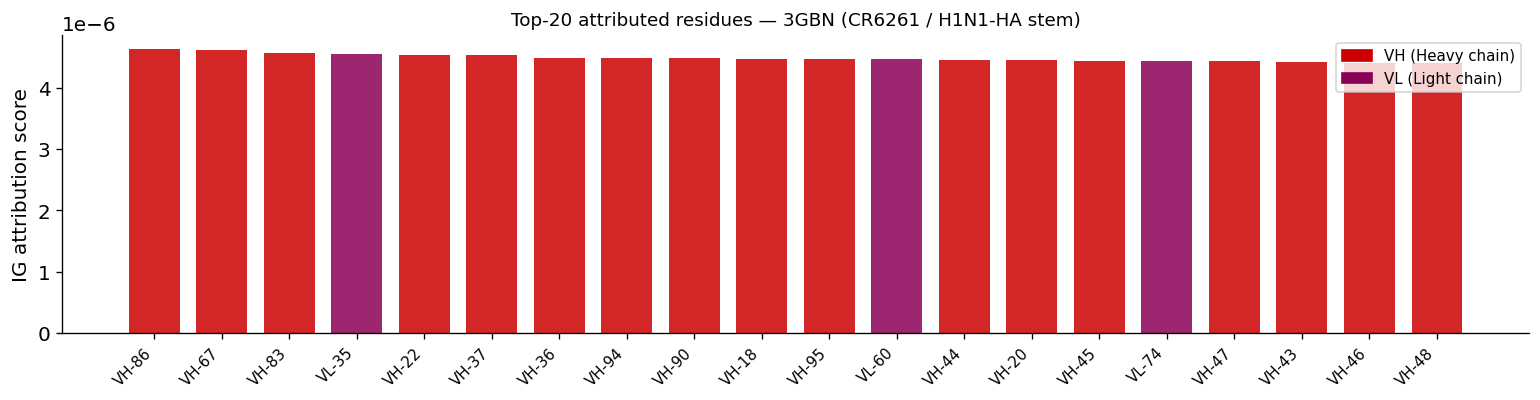

Saved: D:\explainable_AL\publication_repo\notebooks\ig_top20_residues.png


In [10]:
if HAS_PER_RESIDUE:
    # Top-20 attributed residues across VH and VL
    labels = ([f'VH-{i+1}' for i in range(len(vh_seq))] +
              [f'VL-{i+1}' for i in range(len(vl_seq))])
    top20_idx  = np.argsort(per_residue_scores)[::-1][:20]
    top20_vals = per_residue_scores[top20_idx]
    top20_lbl  = [labels[i] for i in top20_idx]
    colors_bar = ['#CC0000' if lbl.startswith('VH') else '#8B0057' for lbl in top20_lbl]

    fig, ax = plt.subplots(figsize=(13, 3.5))
    bars = ax.bar(range(len(top20_vals)), top20_vals, color=colors_bar, alpha=0.85, width=0.75)
    ax.set_xticks(range(len(top20_vals)))
    ax.set_xticklabels(top20_lbl, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('IG attribution score')
    ax.set_title('Top-20 attributed residues — 3GBN (CR6261 / H1N1-HA stem)', fontsize=11)
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color='#CC0000', label='VH (Heavy chain)'),
                        Patch(color='#8B0057', label='VL (Light chain)')],
              fontsize=9, loc='upper right')
    plt.tight_layout()
    out_p = REPO / 'notebooks' / 'ig_top20_residues.png'
    plt.savefig(out_p, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out_p}')
else:
    print('Attribution not available.')


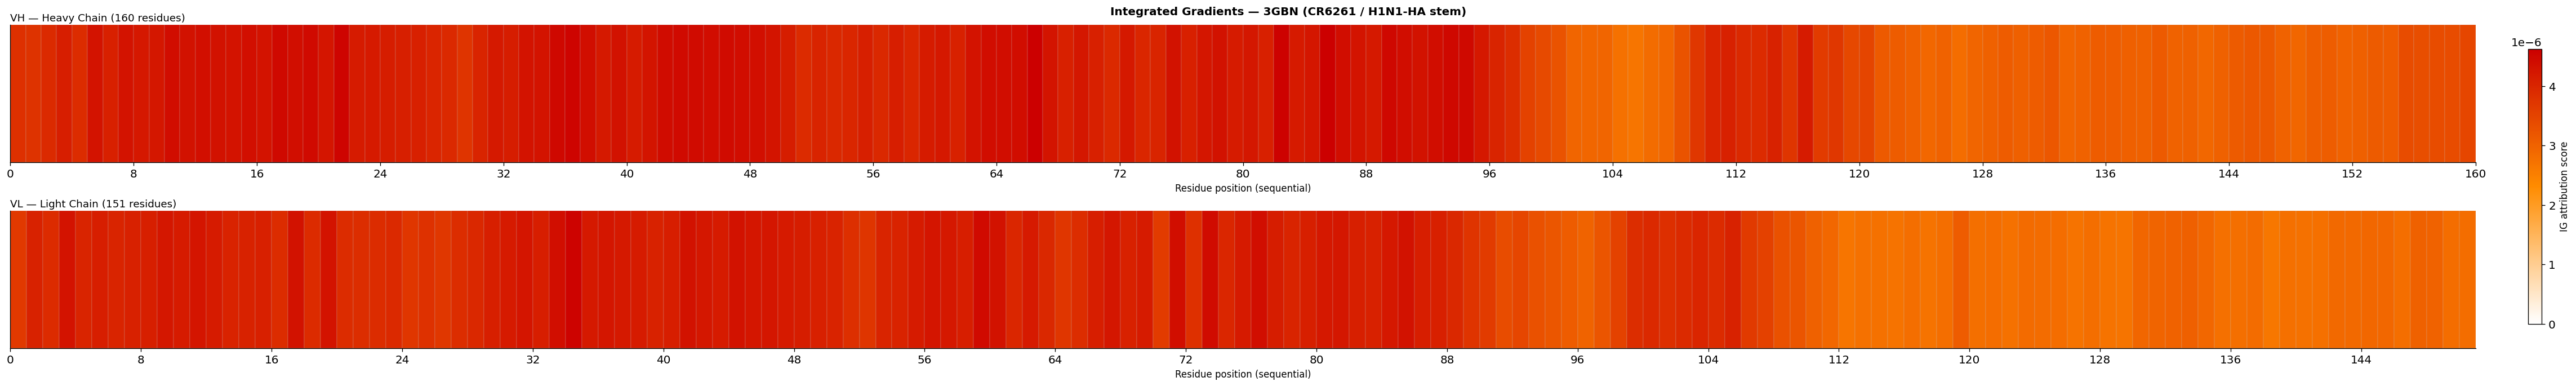

Saved: D:\explainable_AL\publication_repo\notebooks\ig_residue_heatmap.png


In [11]:
if HAS_PER_RESIDUE:
    # ── Paper-style heatmap: white (low) → orange → red (high) ──────────────
    from matplotlib.colors import LinearSegmentedColormap
    paper_cmap = LinearSegmentedColormap.from_list(
        'paper_ig', ['#FFFFFF', '#FF8C00', '#CC0000'], N=256)

    norm_h = mcolors.Normalize(vmin=0, vmax=per_residue_scores.max())

    fig, axes = plt.subplots(2, 1,
                              figsize=(max(14, (len(vh_seq)+len(vl_seq))//8), 5.5),
                              constrained_layout=True)

    for ax, seq, scores, label, chain in zip(
            axes, [vh_seq, vl_seq], [vh_scores, vl_scores],
            ['VH — Heavy Chain', 'VL — Light Chain'], [HEAVY_CHAIN, LIGHT_CHAIN]):
        L = len(seq)
        for i, (aa, s) in enumerate(zip(seq, scores)):
            col = paper_cmap(norm_h(s))
            ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=col, ec='#CCCCCC', lw=0.15))
            if L <= 140:
                bright = norm_h(s) > 0.55
                ax.text(i+0.5, 0.5, aa, ha='center', va='center',
                        fontsize=max(4, 8-L//30),
                        color='white' if bright else '#333333', fontweight='bold')
        ax.set_xlim(0, L); ax.set_ylim(0, 1); ax.set_yticks([])
        ax.set_xticks(range(0, L+1, max(1, L//18)))
        ax.set_xlabel('Residue position (sequential)', fontsize=10)
        ax.set_title(f'{label} ({L} residues)', fontsize=11, loc='left', pad=4)

    sm = plt.cm.ScalarMappable(cmap=paper_cmap, norm=norm_h)
    cbar = plt.colorbar(sm, ax=axes, orientation='vertical', pad=0.01, shrink=0.85)
    cbar.set_label('IG attribution score', fontsize=10)
    fig.suptitle('Integrated Gradients — 3GBN (CR6261 / H1N1-HA stem)',
                 fontsize=12, fontweight='bold', y=1.01)

    out_p = REPO / 'notebooks' / 'ig_residue_heatmap.png'
    plt.savefig(out_p, dpi=200, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out_p}')
else:
    print('Heatmap not available.')


## Step 6 — 3D Structure Mapping (py3Dmol)

Maps IG scores to B-factors in the 3GBN crystal structure (CR6261/H1N1-HA stem).  
Residues are coloured by attribution strength; top-10 attributed residues shown as spheres.

```bash
pip install py3Dmol
```

In [12]:
if HAS_PER_RESIDUE:
    try:
        import py3Dmol
        from Bio.Align import PairwiseAligner
        from Bio.Align import substitution_matrices

        # Normalise scores 0-100 (matching paper B-factor scale)
        def norm100(arr): return 100.0 * arr / (arr.max() + 1e-9)
        vh_n = norm100(vh_scores)
        vl_n = norm100(vl_scores)

        # Map VH scores to PDB residue numbers via sequence alignment
        def align_and_map(chain_obj, seq_query, scores_norm):
            from Bio.PDB.Polypeptide import protein_letters_3to1
            pdb_residues = [(r.get_id()[1], protein_letters_3to1.get(r.resname,'X'))
                            for r in chain_obj.get_residues()
                            if BioPDB.is_aa(r, standard=True)]
            pdb_seq = ''.join(aa for _, aa in pdb_residues)

            aligner = PairwiseAligner()
            aligner.substitution_matrix = substitution_matrices.load('BLOSUM62')
            aligner.open_gap_score = -10
            aligner.extend_gap_score = -0.5
            aln = next(iter(aligner.align(pdb_seq, seq_query)))

            resi_map = {}
            p_ptr = q_ptr = 0
            aln_str = str(aln).split('\n')
            for i in range(len(aln_str[0])):
                p_c = aln_str[0][i] if i < len(aln_str[0]) else '-'
                q_c = aln_str[2][i] if i < len(aln_str[2]) else '-'
                if p_c != '-' and q_c != '-':
                    if p_ptr < len(pdb_residues) and q_ptr < len(scores_norm):
                        resi_map[pdb_residues[p_ptr][0]] = float(scores_norm[q_ptr])
                if p_c != '-': p_ptr += 1
                if q_c != '-': q_ptr += 1
            return resi_map

        vh_map = align_and_map(pdb_model[HEAVY_CHAIN], vh_seq, vh_n)
        vl_map = align_and_map(pdb_model[LIGHT_CHAIN], vl_seq, vl_n)

        # Build B-factor-replaced PDB string
        lines_out = []
        for line in open(DEMO_PDB).readlines():
            if line.startswith(('ATOM','HETATM')):
                ch   = line[21]
                resi = int(line[22:26].strip())
                bval = (vh_map.get(resi, 0.0) if ch == HEAVY_CHAIN
                        else vl_map.get(resi, 0.0) if ch == LIGHT_CHAIN
                        else 0.0)
                lines_out.append(line[:60] + f'{bval:6.2f}' + line[66:])
            else:
                lines_out.append(line)
        pdb_str = ''.join(lines_out)

        # Save B-factor PDB
        bfac_path = REPO / 'notebooks' / 'ig_bfactor_3GBN.pdb'
        bfac_path.write_text(pdb_str)
        print(f'B-factor PDB saved: {bfac_path.name}')

        # ── py3Dmol — paper-style: white→red gradient by B-factor ─────────
        view = py3Dmol.view(width=900, height=580)
        view.addModel(pdb_str, 'pdb')

        # Antigen chains: light blue, semi-transparent (matches paper)
        ag_chains = [c.id for c in pdb_model.get_chains()
                     if c.id not in (HEAVY_CHAIN, LIGHT_CHAIN)]
        for cid in ag_chains:
            view.setStyle({'chain': cid},
                          {'cartoon': {'color': '#87CEEB', 'opacity': 0.65}})

        # Antibody: cartoon coloured white→orange→red by B-factor (attribution)
        # Matches paper's PyMOL: spectrum b, white_red
        for cid in (HEAVY_CHAIN, LIGHT_CHAIN):
            view.setStyle({'chain': cid},
                          {'cartoon': {'colorscheme': {
                              'prop': 'b',
                              'gradient': 'linear',
                              'colors': ['#FFFFFF', '#FF8C00', '#CC0000'],
                              'min': 0, 'max': 100}}})

        # High-attribution residues (B > 60): sticks, matching paper
        all_scores = {**{(HEAVY_CHAIN, r): s for r, s in vh_map.items()},
                      **{(LIGHT_CHAIN, r): s for r, s in vl_map.items()}}
        top10 = sorted(all_scores, key=all_scores.get, reverse=True)[:10]
        for ch, resi in top10:
            view.addStyle({'chain': ch, 'resi': str(resi)},
                          {'stick': {'color': '#CC0000', 'radius': 0.3}})
            view.addStyle({'chain': ch, 'resi': str(resi), 'atom': 'CA'},
                          {'sphere': {'color': '#CC0000', 'radius': 0.55}})
            view.addLabel(f'{ch}{resi}',
                          {'fontColor': 'white', 'fontSize': 9,
                           'backgroundColor': '#333333', 'backgroundOpacity': 0.6},
                          {'chain': ch, 'resi': str(resi), 'atom': 'CA'})

        view.setBackgroundColor('#1a1a2e')
        view.zoomTo({'chain': HEAVY_CHAIN})
        view.show()

        print(f'\nTop-10 attributed residues (white→red scale):')
        for i, (ch, resi) in enumerate(top10, 1):
            s = all_scores[(ch, resi)]
            print(f'  {i:2}. Chain {ch}  residue {resi:4d}  score={s:5.1f}/100')

    except ImportError:
        print('py3Dmol not installed: pip install py3Dmol')
    except Exception as e:
        import traceback; traceback.print_exc()
else:
    print('3D mapping not available.')


B-factor PDB saved: ig_bfactor_3GBN.pdb


3Dmol.js failed to load for some reason. Please check your browser console for error messages.


Top-10 attributed residues (white→red scale):
   1. Chain L  residue   36  score=100.0/100
   2. Chain H  residue   66  score= 99.7/100
   3. Chain H  residue   22  score= 98.1/100
   4. Chain H  residue   37  score= 98.1/100
   5. Chain L  residue   61  score= 97.8/100
   6. Chain L  residue   75  score= 97.4/100
   7. Chain H  residue   36  score= 97.1/100
   8. Chain H  residue   18  score= 96.6/100
   9. Chain L  residue   35  score= 96.3/100
  10. Chain L  residue   78  score= 96.2/100


## Results Summary

| Metric | This run | Paper (3gbn_h1) |
|---|---|---|
| Recall@2% (final) | See table above | **89.5%** |
| Spearman ρ (final) | See table above | **0.892** |
| Kernel | Tanimoto | Tanimoto |
| Acquisition | UCB (β=1) | UCB (β=1) |
| Budget | 10% | 10% |

### Output files
| File | Description |
|---|---|
| `notebooks/al_learning_curve.png` | Recall@2% and Spearman ρ per cycle |
| `notebooks/ig_pca_components.png` | IG attribution by PCA component |
| `notebooks/ig_residue_heatmap.png` | Per-residue VH/VL heatmap |
| `notebooks/ig_bfactor_3GBN.pdb` | PDB with B-factors = IG scores |

### Tips
- For your own dataset: set `DEMO_MODE = False` and provide `CSV_PATH`
- To annotate CDR regions: see the `CDR_REGIONS` dict in the heatmap cell
- To compare kernels/protocols: change `KERNEL` and `PROTOCOL` above

---
*Active Learning framework for Antibody Binding Affinity Prediction — ACML 2026*